# 04 · Métricas de negocio (Fase 3) y variables v2 (Fase 4)

**Parte A – Fase 3:** definir qué significa "éxito" para la IPS, antes de entrenar modelos. Si no, terminamos optimizando una métrica que no le sirve a nadie.

**Parte B – Fase 4:** probar las variables nuevas **por bloques** (solo entra lo que mejora) y verificar qué medidas técnicas necesita cada modelo: validación cruzada, estandarización, regularización.

> Todo se evalúa con **validación cruzada temporal** en enero–junio. Julio (test) no se toca.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import funciones_inasistencia as fi
import funciones_modelado as fm

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)
fm.estilo_graficos()

import json
from sklearn.model_selection import KFold

dataset = pd.read_parquet("dataset_modelo.parquet")
with open("modelos/seleccion_eda.json", encoding="utf-8") as archivo:
    seleccion = json.load(archivo)

desarrollo = dataset[dataset["particion"].isin(["train", "validacion"])].sort_values("fecha_cita").reset_index(drop=True)
y = desarrollo["no_asiste"]
fechas = desarrollo["fecha_cita"]
folds = fm.folds_temporales(fechas)

for i, (tr, va) in enumerate(folds, start=1):
    print(f"Fold {i}: entrena {fechas.iloc[tr].min().date()} a {fechas.iloc[tr].max().date()} ({len(tr):,}) "
          f"→ valida {fechas.iloc[va].min().date()} a {fechas.iloc[va].max().date()} ({len(va):,})")

Fold 1: entrena 2026-01-02 a 2026-02-28 (85,638) → valida 2026-03-02 a 2026-03-31 (45,221)
Fold 2: entrena 2026-01-02 a 2026-03-31 (130,859) → valida 2026-04-01 a 2026-04-30 (38,197)
Fold 3: entrena 2026-01-02 a 2026-04-30 (169,056) → valida 2026-05-02 a 2026-05-30 (42,346)
Fold 4: entrena 2026-01-02 a 2026-05-30 (211,402) → valida 2026-06-01 a 2026-06-30 (38,719)


# PARTE A · Fase 3: definir el éxito en términos del negocio

## 3.1 Capacidad operativa
La herramienta entrega cada día la lista de citas de mañana ordenada por riesgo. El equipo **no puede llamar a todos**, así que la pregunta real es:

> *"Si llamo a las N citas de mayor riesgo, ¿cuántas de esas son realmente inasistencias (**precisión**) y qué porcentaje de todas las inasistencias del día logro cubrir (**recall**)?"*

Por eso la métrica principal no es solo la AUC, sino la **precisión y el recall en el top-N diario**.

In [2]:
citas_por_dia = desarrollo[desarrollo["dia_semana"] != "Sábado"].groupby("fecha_cita").size()
print(f"Citas elegibles por día hábil: promedio {citas_por_dia.mean():.0f}, mediana {citas_por_dia.median():.0f}, "
      f"máximo {citas_por_dia.max():.0f}")
print(f"Inasistencias esperadas por día: {citas_por_dia.mean() * y.mean():.0f}")

Citas elegibles por día hábil: promedio 1835, mediana 1969, máximo 2198
Inasistencias esperadas por día: 592


**Supuesto de capacidad (parametrizable):** un equipo de call center puede hacer unas 150–200 llamadas efectivas al día, lo que equivale aproximadamente al **10 % de las citas diarias**. También evaluamos un escenario del **30 %** (por ejemplo, con mensajes automáticos de WhatsApp/SMS, que son más baratos).

## 3.2 Costo de una inasistencia vs. costo de una llamada
Una llamada vale la pena si **el beneficio esperado supera su costo**:

$$\underbrace{p \times \text{efectividad} \times \text{costo del cupo perdido}}_{\text{beneficio esperado}} > \text{costo de la llamada}$$

Despejando, se llama a una cita si su probabilidad de inasistencia $p$ supera:

$$p^* = \frac{\text{costo llamada}}{\text{efectividad} \times \text{costo cupo}}$$

> ⚠️ Los valores siguientes son **supuestos de referencia** para el ejercicio. La IPS debe reemplazarlos por sus costos reales en `modelos/config_negocio.json`.

In [3]:
negocio = {
    "CAPACIDAD_PRINCIPAL": 0.10,          # % de citas del día que se pueden llamar
    "CAPACIDAD_AMPLIADA": 0.30,           # escenario con mensajes automáticos
    "COSTO_CUPO_PERDIDO": 45_000,         # COP: valor aproximado de una consulta no utilizada (supuesto)
    "COSTO_LLAMADA": 2_500,               # COP: ~5 minutos de un agente (supuesto)
    "EFECTIVIDAD_LLAMADA": 0.25,          # fracción de inasistencias que la llamada evita (supuesto; literatura 20-40 %)
}
negocio["UMBRAL_COSTO_BENEFICIO"] = negocio["COSTO_LLAMADA"] / (negocio["EFECTIVIDAD_LLAMADA"] * negocio["COSTO_CUPO_PERDIDO"])
with open("modelos/config_negocio.json", "w", encoding="utf-8") as archivo:
    json.dump(negocio, archivo, indent=2)

print(f"Umbral de costo-beneficio p* = {negocio['UMBRAL_COSTO_BENEFICIO']:.2f}")
print("→ Conviene llamar a toda cita con probabilidad de inasistencia mayor a "
      f"{negocio['UMBRAL_COSTO_BENEFICIO']:.0%}")

Umbral de costo-beneficio p* = 0.22
→ Conviene llamar a toda cita con probabilidad de inasistencia mayor a 22%


**Interpretación:** con estos supuestos, llamar es rentable desde un riesgo de ~22 %, lo que incluye a la mayoría de las citas. Entonces **el límite real es la capacidad, no el costo**: el objetivo es que las N llamadas disponibles vayan a las citas de mayor riesgo. Esto confirma que la métrica principal es la **precisión en el top-N diario**.

Para el **sobreagendamiento** es distinto: ahí sí importa que la probabilidad sea **creíble** (calibrada). Si el modelo dice 40 %, deben faltar ~40 de cada 100 citas; si no, se sobreagenda de más o de menos.

## 3.3 Ficha de métricas

In [4]:
ficha = pd.DataFrame([
    ["AUC-ROC", "Probabilidad de que una inasistencia reciba más riesgo que una asistencia", "Capacidad de ordenar (ranking)", "> 0,5 (azar); mayor es mejor"],
    ["PR-AUC", "Precisión promedio a lo largo de todos los umbrales", "Útil cuando la clase positiva es minoritaria", "Base = tasa de inasistencia (~0,32)"],
    ["Brier", "Error cuadrático medio de la probabilidad", "Calibración + discriminación", "Menor es mejor; base = 0,32 × 0,68 ≈ 0,218"],
    ["Precisión@10%", "De las citas marcadas (top 10 % del día), % que realmente no asistió", "Calidad de las llamadas: MÉTRICA PRINCIPAL", "Base = 32 % (llamar al azar)"],
    ["Recall@10%", "De todas las inasistencias, % que quedó en el top 10 %", "Cobertura del problema", "Base = 10 %"],
    ["Especificidad@10%", "De los que sí asistieron, % que NO se marcó", "Evita molestar a quien sí viene", "Base = 90 %"],
    ["F1@10%", "Media armónica de precisión y recall", "Balance", "—"],
    ["Curva de calibración", "Probabilidad predicha vs. tasa real por grupos", "Credibilidad para sobreagendar", "Cerca de la diagonal"],
], columns=["Métrica", "Qué mide", "Para qué sirve", "Referencia"])
ficha.style.set_properties(**{"text-align": "left", "white-space": "normal"})

,Métrica,Qué mide,Para qué sirve,Referencia
0,AUC-ROC,Probabilidad de que una inasistencia reciba más riesgo que una asistencia,Capacidad de ordenar (ranking),"> 0,5 (azar); mayor es mejor"
1,PR-AUC,Precisión promedio a lo largo de todos los umbrales,Útil cuando la clase positiva es minoritaria,"Base = tasa de inasistencia (~0,32)"
2,Brier,Error cuadrático medio de la probabilidad,Calibración + discriminación,"Menor es mejor; base = 0,32 × 0,68 ≈ 0,218"
3,Precisión@10%,"De las citas marcadas (top 10 % del día), % que realmente no asistió",Calidad de las llamadas: MÉTRICA PRINCIPAL,Base = 32 % (llamar al azar)
4,Recall@10%,"De todas las inasistencias, % que quedó en el top 10 %",Cobertura del problema,Base = 10 %
5,Especificidad@10%,"De los que sí asistieron, % que NO se marcó",Evita molestar a quien sí viene,Base = 90 %
6,F1@10%,Media armónica de precisión y recall,Balance,—
7,Curva de calibración,Probabilidad predicha vs. tasa real por grupos,Credibilidad para sobreagendar,Cerca de la diagonal


> **¿Por qué no usar el umbral 0,5?** Con una tasa de inasistencia del 32 %, un umbral fijo de 0,5 marca muy pocas citas, y la cantidad marcada cambia cada día. En operación lo que existe es una **capacidad fija por día**, así que el umbral natural es "el top-N de cada día". Así se comparan todos los modelos en igualdad de condiciones.

# PARTE B · Fase 4: variables v2 y medidas técnicas

## 4.0 Medidas requeridas para los modelos
Antes de agregar variables, verificamos qué necesita cada tipo de modelo:

| Medida | Regresión logística | Random Forest / Gradient Boosting |
|---|---|---|
| **Validación cruzada temporal** | Sí | Sí |
| **Estandarización** (media 0, desviación 1) | **Sí**: los coeficientes y la regularización dependen de la escala | No: los árboles cortan por umbrales, la escala no importa |
| **Regularización** | **Sí**: parámetro `C` (L2) controla la multicolinealidad y el sobreajuste | Sí, pero de otra forma: profundidad, hojas mínimas, tasa de aprendizaje |
| **One-hot de categorías** | Sí | No: manejo nativo o códigos ordinales |
| **Imputación de vacíos** | Sí (+ indicador de vacío) | HGB/LightGBM: no (nativo). RF: sí |
| **Balanceo de clases** | Opcional (`class_weight`) | Opcional (`class_weight`) |

Lo comprobamos con experimentos.

### Experimento 1: ¿por qué validación cruzada **temporal** y no aleatoria?

In [5]:
variables_v1 = seleccion["variables_v1"]
X = desarrollo[variables_v1]
parametros_hgb = {"max_iter": 300, "learning_rate": 0.05}

temporal = fm.evaluar_en_folds("hist_gradient_boosting", X, y, fechas, folds, parametros_hgb)

folds_aleatorios = list(KFold(n_splits=4, shuffle=True, random_state=42).split(X))
aleatorio = fm.evaluar_en_folds("hist_gradient_boosting", X, y, fechas, folds_aleatorios, parametros_hgb)

comparacion = pd.DataFrame({
    "AUC por fold (temporal)": temporal["AUC"].round(3).values,
    "AUC por fold (aleatorio)": aleatorio["AUC"].round(3).values,
}, index=["fold 1", "fold 2", "fold 3", "fold 4"])
display(comparacion)
print(f"Temporal:  {temporal['AUC'].mean():.3f} ± {temporal['AUC'].std():.3f}")
print(f"Aleatorio: {aleatorio['AUC'].mean():.3f} ± {aleatorio['AUC'].std():.3f}")

,AUC por fold (temporal),AUC por fold (aleatorio)
fold 1,0.675,0.677
fold 2,0.659,0.681
fold 3,0.670,0.686
fold 4,0.668,0.683


Temporal:  0.668 ± 0.007
Aleatorio: 0.682 ± 0.004


**Lectura:** la validación aleatoria da una AUC **más alta**, pero es un espejismo. Al mezclar fechas, el modelo entrena con citas de junio y se evalúa en marzo: "ve el futuro". En producción eso nunca pasa. La validación temporal es la estimación **honesta**.

Además, la AUC temporal **varía entre folds** (cada mes es distinto). Por eso reportamos siempre **media ± desviación**: evaluar con un solo mes podría darnos un resultado optimista o pesimista por suerte.

### Experimento 2: estandarización en la regresión logística

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categoricas, numericas = fm.separar_tipos(X)
train_idx, valid_idx = folds[-1]   # ene-may -> jun

def logistica(escalar, C=1.0):
    pasos_num = [("imputar", SimpleImputer(strategy="median", add_indicator=True))]
    if escalar:
        pasos_num.append(("escalar", StandardScaler()))
    prep = ColumnTransformer([("num", Pipeline(pasos_num), numericas),
                              ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=100), categoricas)])
    return Pipeline([("prep", prep), ("clf", LogisticRegression(C=C, max_iter=3000))])

for escalar in [False, True]:
    modelo = logistica(escalar).fit(X.iloc[train_idx], y.iloc[train_idx])
    auc = roc_auc_score(y.iloc[valid_idx], modelo.predict_proba(X.iloc[valid_idx])[:, 1])
    iteraciones = modelo.named_steps["clf"].n_iter_[0]
    print(f"Estandarizar={escalar!s:5} | AUC junio = {auc:.3f} | iteraciones hasta converger = {iteraciones}")

Estandarizar=False | AUC junio = 0.651 | iteraciones hasta converger = 3000


Estandarizar=True  | AUC junio = 0.651 | iteraciones hasta converger = 100


**Lectura:** sin estandarizar, el optimizador **agota las 3.000 iteraciones permitidas sin converger**, mientras que con estandarización converge en unas 100. Pasa porque las variables tienen escalas muy distintas (`edad` de 0 a 105, `turno_sin` de −1 a 1, `lead_time` hasta 245). En este caso la AUC final coincide, pero un modelo que no converge tiene coeficientes que no son confiables para interpretar (Fase 7). Además, la penalización `C` castiga de forma desigual a variables con escalas distintas. **Conclusión: la logística requiere estandarización** (ya está incluida en el Pipeline de `funciones_modelado.py`).

### Experimento 3: regularización (parámetro C)
En la regresión logística, `C` es el **inverso** de la fuerza de regularización:
- **C pequeño** → mucha regularización → coeficientes pequeños y modelo más simple (riesgo de subajuste).
- **C grande** → poca regularización → el modelo se ajusta más a los datos (riesgo de sobreajuste y coeficientes inestables por multicolinealidad).

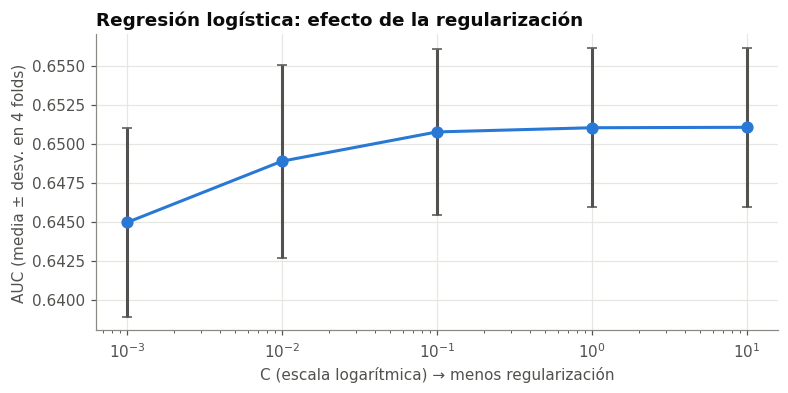

,C,AUC_media,AUC_desv
0,0.001,0.6450,0.0061
1,0.010,0.6489,0.0062
2,0.100,0.6508,0.0053
3,1.000,0.6510,0.0051
4,10.000,0.6510,0.0051


In [7]:
resultados_C = []
for C in [0.001, 0.01, 0.1, 1, 10]:
    r = fm.evaluar_en_folds("logistica", X, y, fechas, folds, {"C": C})
    resultados_C.append({"C": C, "AUC_media": r["AUC"].mean(), "AUC_desv": r["AUC"].std()})
resultados_C = pd.DataFrame(resultados_C)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.errorbar(resultados_C["C"], resultados_C["AUC_media"], yerr=resultados_C["AUC_desv"], color=fm.AZUL,
            marker="o", markersize=7, linewidth=2, capsize=3, ecolor=fm.TINTA_SUAVE)
ax.set_xscale("log")
ax.set_xlabel("C (escala logarítmica) → menos regularización")
ax.set_ylabel("AUC (media ± desv. en 4 folds)")
ax.set_title("Regresión logística: efecto de la regularización")
plt.show()
resultados_C.round(4)

**Lectura:** la AUC casi no cambia (0,645 a 0,651). Solo con C = 0,001 baja un poco, porque el modelo queda demasiado restringido. Con más de 200 mil citas y unas 150 columnas después del one-hot hay datos de sobra, así que el riesgo de sobreajuste de la logística es bajo. Aun así, la regularización **se mantiene**: estabiliza los coeficientes de variables correlacionadas (por ejemplo, `n_diagnosticos_previos` y `n_atenciones_90d`, con r = 0,91), y eso importa para interpretarlos en la Fase 7. El valor definitivo de C se elige en la Fase 5. En los árboles, la regularización equivalente (`min_samples_leaf`, `max_depth`, `learning_rate`) sí es crítica y también se ajusta en la Fase 5.

## 4.1–4.4 Evaluación de las variables v2 por bloques

**Regla:** agregamos los bloques uno por uno, de forma acumulada. Un bloque **entra** si mejora la AUC media en al menos **0,002** en el modelo de árboles (HGB) o en la logística. Si no mejora, no entra: una variable que no aporta solo agrega complejidad y riesgo de fallas en producción.

| Bloque | Variables | Hipótesis |
|---|---|---|
| Historial por especialidad (4.1) | inasistencia del paciente **en esa especialidad** | Alguien puede faltar a odontología pero nunca al médico |
| Reprogramaciones (4.2) | reprogramaciones previas | Quien reprograma mucho tiene agenda inestable |
| Carga de agenda (4.3) | otras citas el mismo día, en los 7 días anteriores y siguientes | Varias citas juntas → más probable que falte a alguna |
| Interacciones (4.4) | familia × lead time, curso de vida × control | El efecto del lead time depende del servicio (sobre todo para la logística) |

In [8]:
bloques = seleccion["bloques_v2"]
configuraciones = {"v1 (base)": variables_v1}
acumulado = list(variables_v1)
for nombre_bloque, variables_bloque in bloques.items():
    acumulado = acumulado + variables_bloque
    configuraciones[f"+ {nombre_bloque}"] = list(acumulado)

filas = []
for nombre, variables in configuraciones.items():
    Xc = desarrollo[variables]
    hgb = fm.evaluar_en_folds("hist_gradient_boosting", Xc, y, fechas, folds, parametros_hgb)
    log = fm.evaluar_en_folds("logistica", Xc, y, fechas, folds, {"C": 0.1})
    filas.append({"configuracion": nombre, "n_variables": len(variables),
                  "AUC_HGB": hgb["AUC"].mean(), "desv_HGB": hgb["AUC"].std(),
                  "Precision@10%_HGB": hgb["Precision@10%"].mean(),
                  "AUC_logistica": log["AUC"].mean(), "desv_logistica": log["AUC"].std()})
    print(f"{nombre:<28} HGB {hgb['AUC'].mean():.4f} | logística {log['AUC'].mean():.4f}")

tabla_bloques = pd.DataFrame(filas)
tabla_bloques["mejora_HGB"] = tabla_bloques["AUC_HGB"].diff()
tabla_bloques["mejora_logistica"] = tabla_bloques["AUC_logistica"].diff()
tabla_bloques.round(4)

v1 (base)                    HGB 0.6680 | logística 0.6508


+ historial_especialidad     HGB 0.6705 | logística 0.6511


+ reprogramaciones           HGB 0.6702 | logística 0.6512


+ carga_agenda               HGB 0.6756 | logística 0.6524


+ interacciones              HGB 0.6749 | logística 0.6551


,configuracion,n_variables,AUC_HGB,desv_HGB,Precision@10%_HGB,AUC_logistica,desv_logistica,mejora_HGB,mejora_logistica
0,v1 (base),35,0.6680,0.0069,0.6054,0.6508,0.0053,NaN,NaN
1,+ historial_especialidad,40,0.6705,0.0065,0.6108,0.6511,0.0060,0.0025,0.0003
2,+ reprogramaciones,41,0.6702,0.0064,0.6090,0.6512,0.0060,-0.0004,0.0002
3,+ carga_agenda,44,0.6756,0.0066,0.6165,0.6524,0.0062,0.0054,0.0011
4,+ interacciones,46,0.6749,0.0067,0.6118,0.6551,0.0062,-0.0007,0.0027


In [9]:
# Decisión automática, bloque por bloque, con la regla definida arriba
MEJORA_MINIMA = 0.002
variables_finales = list(variables_v1)
decisiones = []
for i, (nombre_bloque, variables_bloque) in enumerate(bloques.items(), start=1):
    fila = tabla_bloques.iloc[i]
    entra = (fila["mejora_HGB"] >= MEJORA_MINIMA) or (fila["mejora_logistica"] >= MEJORA_MINIMA)
    if entra:
        variables_finales += variables_bloque
    decisiones.append({"bloque": nombre_bloque, "mejora_HGB": round(fila["mejora_HGB"], 4),
                       "mejora_logistica": round(fila["mejora_logistica"], 4),
                       "decision": "ENTRA" if entra else "no entra"})
pd.DataFrame(decisiones)

,bloque,mejora_HGB,mejora_logistica,decision
0,historial_especialidad,0.0025,0.0003,ENTRA
1,reprogramaciones,-0.0004,0.0002,no entra
2,carga_agenda,0.0054,0.0011,ENTRA
3,interacciones,-0.0007,0.0027,ENTRA


> **Nota metodológica:** la evaluación es acumulada, así que la mejora de un bloque se mide *sobre* los anteriores. Si un bloque no entra, los siguientes igual se evaluaron con él incluido. Para confirmar que la selección final no depende de eso, abajo evaluamos la configuración elegida de forma directa.

In [10]:
final_hgb = fm.evaluar_en_folds("hist_gradient_boosting", desarrollo[variables_finales], y, fechas, folds, parametros_hgb)
final_log = fm.evaluar_en_folds("logistica", desarrollo[variables_finales], y, fechas, folds, {"C": 0.1})
print(f"Variables finales: {len(variables_finales)}")
print(f"HGB:       AUC {final_hgb['AUC'].mean():.4f} ± {final_hgb['AUC'].std():.4f} | Precisión@10% {final_hgb['Precision@10%'].mean():.3f}")
print(f"Logística: AUC {final_log['AUC'].mean():.4f} ± {final_log['AUC'].std():.4f} | Precisión@10% {final_log['Precision@10%'].mean():.3f}")

Variables finales: 45
HGB:       AUC 0.6752 ± 0.0067 | Precisión@10% 0.617
Logística: AUC 0.6548 ± 0.0062 | Precisión@10% 0.573


## Exportar `dataset_modelo_v2.parquet` y la lista de variables

In [11]:
dataset_v2 = dataset[fi.COLUMNAS_ID + variables_finales]
dataset_v2.to_parquet("dataset_modelo_v2.parquet", index=False)

with open("modelos/variables_modelo.json", "w", encoding="utf-8") as archivo:
    json.dump({"variables": variables_finales, "decisiones_bloques": decisiones}, archivo, ensure_ascii=False, indent=2)

print(f"dataset_modelo_v2.parquet: {dataset_v2.shape[0]:,} filas × {len(variables_finales)} variables")

dataset_modelo_v2.parquet: 337,375 filas × 45 variables


## Conclusiones
1. **Validación cruzada temporal: obligatoria.** La aleatoria sobreestima el desempeño.
2. **Estandarización: obligatoria para la logística** (convergencia y regularización justa); innecesaria para los árboles.
3. **Regularización:** en la logística casi no cambia la AUC (hay datos de sobra), pero se mantiene para estabilizar los coeficientes. En los árboles se controla con sus hiperparámetros (Fase 5).
4. **Variables v2:** solo entran los bloques que mejoran de forma medible (ver tabla de decisiones).
5. **Negocio:** con los supuestos de costo, el límite es la **capacidad** de llamadas, no el costo. Métrica principal: **precisión@10 % diaria**. Métrica secundaria para sobreagendar: **calibración (Brier)**.